## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/"

The junctions are loaded from the following path: /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT
The files in the path are: ['Choroid_plexus_epithelial_cells_APOE4_female.juncswbarcodes', 'Pituitary_cells_5xFAD_male.juncswbarcodes', 'Hindbrain_neurons_1_6mo_male.barcodes', 'Interneurons_2_5xFAD_male.juncswbarcodes', 'Hindbrain_neurons_1_5xFAD_female.juncswbarcodes', 'Cerebellum_interneurons_6mo_female.juncs', 'Striatal_neurons_2_6mo_female.juncswbarcodes', 'Striatal_neurons_1_6mo_male.juncswbarcodes', 'Cerebellum_interneurons_21mo_male.juncswbarcodes', 'Ependymal_cells_5xFAD_female.juncs', 'Hindbrain_neurons_2_APOE4_female.juncs', 'Striatal_neurons_1_21mo_male.barcodes', 'Hindbrain_neurons_2_APOE4_female.juncswbarcodes', 'Vascular_leptomeningeal_cells_APOE4_female.barcodes', 'Cortical_projection_neurons_3_21mo_female.juncswbarcodes', 'Interbrain_and_midbrain_neurons_1_21mo_male.barcodes', 'OB_neurons_3_APOE4_female.barcodes', 'Inferior_olivary_nucleus_n

### Let's first define some parameters for the analysis

In [2]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.basic.annotation.gtf" 

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "test_intron_clusters"
junc_bed_file= output_path + "test_juncs.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
min_num_cells_wjunc = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*.juncswbarcodes" # depends on how you ran regtools 

### Run intron clustering 

In [3]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,
                       run_notebook = True)

Loading files obtained from single_cell sequencing


100%|██████████| 1/1 [01:19<00:00, 79.06s/it]


The total number of files that could not be read is 1 as these had no junctions
The gtf file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'mgi_id', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 111.65 seconds
The number of unique exons is 323028
The number of unique transcript ids is 80576
The number of unique gene ids is 55358
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Cleaning up 'chrom' column
Making gr object from all junctions across all cell types
The number of junctions prior to assessing distance to exons is 184317
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 142363
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 125703
The number of junctions after removing singletons is 142362
The number of clusters after removing singletons is 125702
The number of clusters after filtering for shared splice sites is 7347
The number of junctions after filtering for shared splice sites is 23986
Refining intron clusters to account for junction usage ratio threshold...
Done refining cluster

In [4]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [5]:
dat_vis

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,101847705,102186795,+,339090,85,10_101847705_102186795,5021,10,101847705,102186795,+,101847593,101847705,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000179929.8,ENSMUSE00000845828.2
1,10,101994920,102186795,+,191875,17,10_101994920_102186795,5021,10,101994920,102186795,+,101994718,101994920,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000163753.8,ENSMUSE00000744776.2
2,10,102186845,102206193,+,19348,110,10_102186845_102206193,5022,10,102186845,102206193,+,102186806,102186845,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000179929.8,ENSMUSE00001010601.2
3,10,102186845,102214012,+,27167,46,10_102186845_102214012,5022,10,102186845,102214012,+,102186806,102186845,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000179929.8,ENSMUSE00001010601.2
4,10,102206254,102214012,+,7758,139,10_102206254_102214012,5022,10,102206254,102214012,+,102206193,102206254,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000179929.8,ENSMUSE00000640696.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19836,Y,1280439,1282900,-,2461,204,Y_1280439_1282900,8995,Y,1280439,1282900,-,1280309,1280439,ENSMUSG00000069045.12,Ddx3y,ENSMUST00000091190.12,ENSMUSE00000568575.2
19837,Y,1280439,1284321,-,3882,7,Y_1280439_1284321,8995,Y,1280439,1284321,-,1280309,1280439,ENSMUSG00000069045.12,Ddx3y,ENSMUST00000091190.12,ENSMUSE00000568575.2
19838,Y,1282948,1284321,-,1373,96,Y_1282948_1284321,8995,Y,1282948,1284321,-,1282900,1282948,ENSMUSG00000069045.12,Ddx3y,ENSMUST00000091190.12,ENSMUSE00000568579.2
19839,Y,90804686,90827617,+,22931,503,Y_90804686_90827617,8993,Y,90804686,90827617,+,90804564,90804686,ENSMUSG00000096768.9,Gm47283,ENSMUST00000179483.9,ENSMUSE00001269726.2


     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
9993     2     156371.390   156375.700      +           4310            76   
9994     2     156371.390   156378.899      +           7509             4   
9995     2     156375.787   156376.605      +            818            55   
9996     2     156376.689   156378.899      +           2210           113   

         Start_b       End_b               exon_id  
9993  156371.309  156371.390  ENSMUSE00000594293.2  
9994  156371.309  156371.390  ENSMUSE00000594293.2  
9995  156375.700  156375.787  ENSMUSE00000594292.2  
9996  156376.605  156376.689  ENSMUSE00001304489.2  
The junction of interest is 2_156376689_156378899


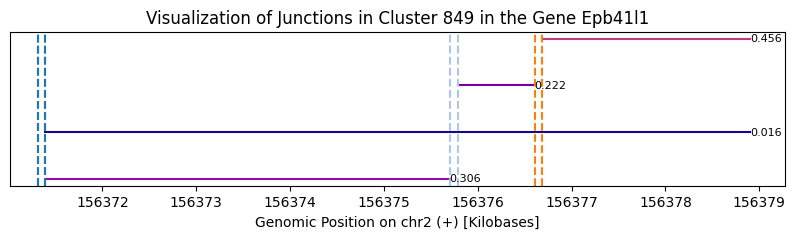

In [6]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [7]:
intron_clusters = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_intron_clusters_50_500000_2_20240425_single_cell.gz" # path to the intron clusters file
output_file = output_path + "test_model_input" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [8]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_intron_clusters_50_500000_2_20240425_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


168it [00:36,  4.65it/s]


Done processing intron clusters
The number of intron clusters evaluated is 6461
The number of junctions evaluated is 19841
The number of cells evaluated is 472943
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 472943
The number of cells per cell type is:
cell_type
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT/Astrocytes_21mo_female.juncswbarcodes                        3937
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT/Astrocytes_21mo_male.juncswbarcodes                          3409
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT/Astrocytes_3mo_female.juncswbarcodes                         5662
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/DT/Astrocytes_3mo_male.juncswbarcodes                           5088
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/L

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [9]:
model_input_data = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_model_input.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...     2109               1   
1  EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...     4878               2   
2  EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...     4915               1   
3  EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...     7841               2   
4  EasySci_001.AACCGATTGCCGTAAGGAGT_/gpfs/commons...      922               1   

             junction_id                gene_id  junc_count  \
0  4_155710111_155711230  ENSMUSG00000029062.15           1   
1  9_106909556_106932648  ENSMUSG00000039716.13           2   
2    9_45809789_45811043  ENSMUSG00000042790.17           1   
3   17_64230494_64231053  ENSMUSG00000000127.16           2   
4    2_76370540_76376321  ENSMUSG00000042359.19           1   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/projects/knowles_singlecell_spli...         1.0  

#### Note that fow now, the values in cell_type default to the cell's path, in the future it will be possible to specify the cell type in the metadata file

In [10]:
# let's see all the columns in the summarized data
print(summarized_data.columns)

Index(['cell_id', 'Cluster', 'Cluster_Counts', 'junction_id', 'gene_id',
       'junc_count', 'cell_type', 'junc_ratio', 'cell_id_index',
       'junction_id_index'],
      dtype='object')


#### We can quickly visualize the overall junction usage ratio distribution across all cells

In [11]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index
0,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,2109,1,4_155710111_155711230,ENSMUSG00000029062.15,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,12953
1,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4878,2,9_106909556_106932648,ENSMUSG00000039716.13,2,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,17848
2,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4915,1,9_45809789_45811043,ENSMUSG00000042790.17,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,18406
3,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,7841,2,17_64230494_64231053,ENSMUSG00000000127.16,2,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,6596
4,EasySci_001.AACCGATTGCCGTAAGGAGT_/gpfs/commons...,922,1,2_76370540_76376321,ENSMUSG00000042359.19,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,1,11026


In [12]:
print(len(summarized_data.cell_id.unique()))

472943


In [13]:
all_cell_ids = summarized_data.cell_id

# clean up each cell_id using .str.split("_/gpfs")[0]
all_cell_ids_clean = [x.split("_/gpfs")[0] for x in all_cell_ids]
summarized_data["cell_id_clean"] = all_cell_ids_clean

In [14]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id_clean
0,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,2109,1,4_155710111_155711230,ENSMUSG00000029062.15,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,12953,EasySci_001.AACCGATTGCCCAGGCTCTT
1,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4878,2,9_106909556_106932648,ENSMUSG00000039716.13,2,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,17848,EasySci_001.AACCGATTGCCCAGGCTCTT
2,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4915,1,9_45809789_45811043,ENSMUSG00000042790.17,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,18406,EasySci_001.AACCGATTGCCCAGGCTCTT
3,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,7841,2,17_64230494_64231053,ENSMUSG00000000127.16,2,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,6596,EasySci_001.AACCGATTGCCCAGGCTCTT
4,EasySci_001.AACCGATTGCCGTAAGGAGT_/gpfs/commons...,922,1,2_76370540_76376321,ENSMUSG00000042359.19,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,1,11026,EasySci_001.AACCGATTGCCGTAAGGAGT


In [15]:
cell_types = summarized_data.cell_type

# keep everything after Leaflet/junctions/RH/ and before .juncswbarcodes
cell_types_clean = [x.split("Leaflet/junctions/DT/")[1].split(".juncswbarcodes")[0] for x in cell_types]
summarized_data["cell_type_clean"] = cell_types_clean

# remove old cell_type column 
summarized_data = summarized_data.drop(columns=["cell_type"])

In [16]:
# turn summarized counts into dataframe 
summarized_data_df = pd.DataFrame(summarized_data.cell_type_clean.value_counts()).reset_index()
summarized_data_df.columns = ["sample", "cell_junction_pairs"]
summarized_data_df = summarized_data_df.sort_values(by="cell_junction_pairs", ascending=False)

# add column mouse sex is everything after last "_" in sample column
summarized_data_df["sex"] = summarized_data_df["sample"].str.split("_").str[-1]
# add column mouse state is everything after second last "_" in sample column
summarized_data_df["state"] = summarized_data_df["sample"].str.split("_").str[-2]
# add cell type is everything before second last "_" in sample 
summarized_data_df["cell_type"] = summarized_data_df["sample"].str.split("_").str[:-2].str.join("_")

In [17]:
len(summarized_data_df.cell_type.unique())

30

In [18]:
print(summarized_data_df.state.unique())

['6mo' '21mo' '5xFAD' 'APOE4' '3mo']


Text(0.5, 1.0, 'Number of cell junction pairs per cell type')

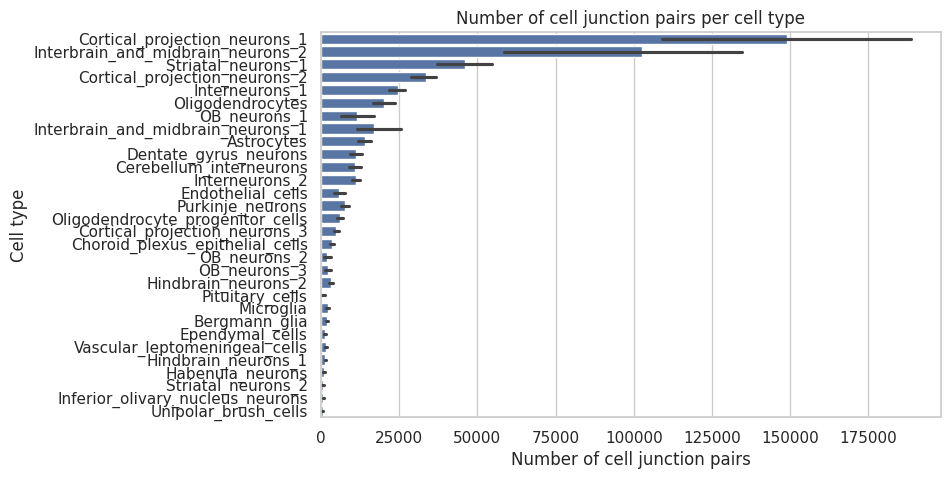

In [19]:
# make barplot of summarized_data_df 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# sort summarized_data_df by cell_junction_pairs
summarized_data_df = summarized_data_df.sort_values(by="cell_junction_pairs", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="cell_junction_pairs", y="cell_type", data=summarized_data_df) 
# xlab add 
plt.xlabel("Number of cell junction pairs")
plt.ylabel("Cell type")
plt.title("Number of cell junction pairs per cell type")

Text(0.5, 1.0, 'Number of cell junction pairs per mouse type/sex')

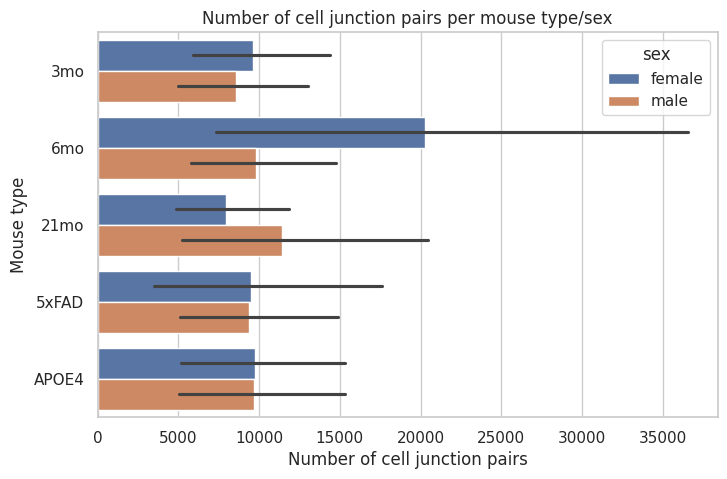

In [20]:
# Make the same plot but now per mouse type and sex 

# reorder state column values so that it's 3mo, 6mo, 21mo 5xFAD, 21mo WT
summarized_data_df["state"] = pd.Categorical(summarized_data_df["state"], ["3mo", "6mo", "21mo", "5xFAD", "APOE4"])

plt.figure(figsize=(8, 5))
sns.barplot(x="cell_junction_pairs", y="state", hue="sex", data=summarized_data_df)
# xlab add
plt.xlabel("Number of cell junction pairs")
plt.ylabel("Mouse type")
plt.title("Number of cell junction pairs per mouse type/sex") 

In [21]:
# rename cell_type column to sample
summarized_data = summarized_data.rename(columns={"cell_type_clean": "sample"})
# merge with sumamrized_datA_df
summarized_data = summarized_data.merge(summarized_data_df, how="left", on="sample")
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id_clean,sample,cell_junction_pairs,sex,state,cell_type
0,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,2109,1,4_155710111_155711230,ENSMUSG00000029062.15,1,1.0,0,12953,EasySci_001.AACCGATTGCCCAGGCTCTT,Oligodendrocyte_progenitor_cells_6mo_male,6702,male,6mo,Oligodendrocyte_progenitor_cells
1,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4878,2,9_106909556_106932648,ENSMUSG00000039716.13,2,1.0,0,17848,EasySci_001.AACCGATTGCCCAGGCTCTT,Oligodendrocyte_progenitor_cells_6mo_male,6702,male,6mo,Oligodendrocyte_progenitor_cells
2,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,4915,1,9_45809789_45811043,ENSMUSG00000042790.17,1,1.0,0,18406,EasySci_001.AACCGATTGCCCAGGCTCTT,Oligodendrocyte_progenitor_cells_6mo_male,6702,male,6mo,Oligodendrocyte_progenitor_cells
3,EasySci_001.AACCGATTGCCCAGGCTCTT_/gpfs/commons...,7841,2,17_64230494_64231053,ENSMUSG00000000127.16,2,1.0,0,6596,EasySci_001.AACCGATTGCCCAGGCTCTT,Oligodendrocyte_progenitor_cells_6mo_male,6702,male,6mo,Oligodendrocyte_progenitor_cells
4,EasySci_001.AACCGATTGCCGTAAGGAGT_/gpfs/commons...,922,1,2_76370540_76376321,ENSMUSG00000042359.19,1,1.0,1,11026,EasySci_001.AACCGATTGCCGTAAGGAGT,Striatal_neurons_1_APOE4_male,64459,male,APOE4,Striatal_neurons_1


In [22]:
# Get number of cell_id_clean unique per mouse state and cell_type 
cells_summ = summarized_data.groupby(["state", "cell_type"])["cell_id_clean"].nunique().reset_index()
# sort by cell_id_clean and make barplot 
cells_summ = cells_summ.sort_values(by="cell_id_clean", ascending=False)


/scratch/ipykernel_35153/2516087553.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_summ = summarized_data.groupby(["state", "cell_type"])["cell_id_clean"].nunique().reset_index()


<Axes: xlabel='cell_id_clean', ylabel='cell_type'>

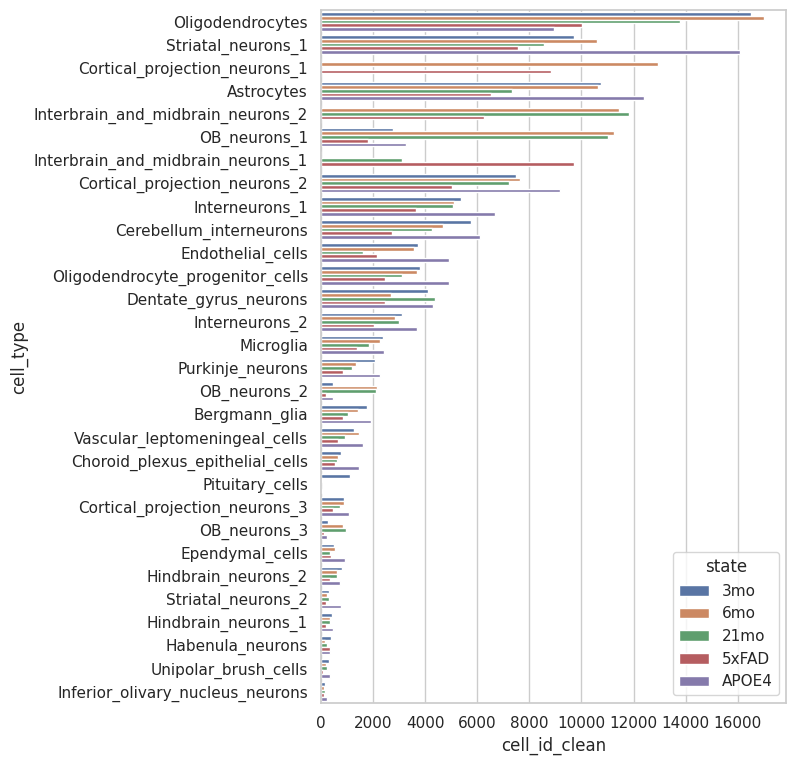

In [23]:
plt.figure(figsize=(6, 9))
sns.barplot(x="cell_id_clean", y="cell_type", hue="state", data=cells_summ)

In [24]:
# remove cell_id column and rename cell_id_clean to cell_id 
summarized_data = summarized_data.drop(columns=["cell_id"])
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})

summarized_data.cell_type.unique()

array(['Oligodendrocyte_progenitor_cells', 'Striatal_neurons_1',
       'Oligodendrocytes', 'Astrocytes', 'Ependymal_cells',
       'Purkinje_neurons', 'Dentate_gyrus_neurons', 'Hindbrain_neurons_2',
       'Cerebellum_interneurons', 'Interneurons_1', 'Interneurons_2',
       'Habenula_neurons', 'Cortical_projection_neurons_2',
       'Interbrain_and_midbrain_neurons_2', 'OB_neurons_1',
       'Endothelial_cells', 'Interbrain_and_midbrain_neurons_1',
       'Cortical_projection_neurons_1', 'Choroid_plexus_epithelial_cells',
       'Bergmann_glia', 'Inferior_olivary_nucleus_neurons', 'Microglia',
       'Pituitary_cells', 'OB_neurons_2', 'Vascular_leptomeningeal_cells',
       'Cortical_projection_neurons_3', 'Hindbrain_neurons_1',
       'Striatal_neurons_2', 'OB_neurons_3', 'Unipolar_brush_cells'],
      dtype=object)

In [25]:
print(model_input_data)

/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_model_input.h5


In [26]:
# calculate number of junctions detected in each cell 
junctions_per_cell = summarized_data.groupby("cell_id")["junction_id"].nunique().reset_index()
junctions_per_cell

,cell_id,junction_id
0,EasySci_001.AACCGATTGCCCAGGCTCTT,4
1,EasySci_001.AACCGATTGCCGTAAGGAGT,2
2,EasySci_001.AACCGATTGCCTTCATTAGA,1
3,EasySci_001.AACCGATTGCGACCTTGATA,2
4,EasySci_001.AACCGATTGCGCCTCAGCAT,1
...,...,...
472938,EasySci_192.TTGGCGCTTCTTCTATAGAG,16
472939,EasySci_192.TTGGTTCTCAAATTGAGAGA,2
472940,EasySci_192.TTGGTTCTCAACGCGCTCCT,6
472941,EasySci_192.TTGGTTCTCAGTAGATGCGC,3


Text(0.5, 0.98, 'Total number of cells: 472943')

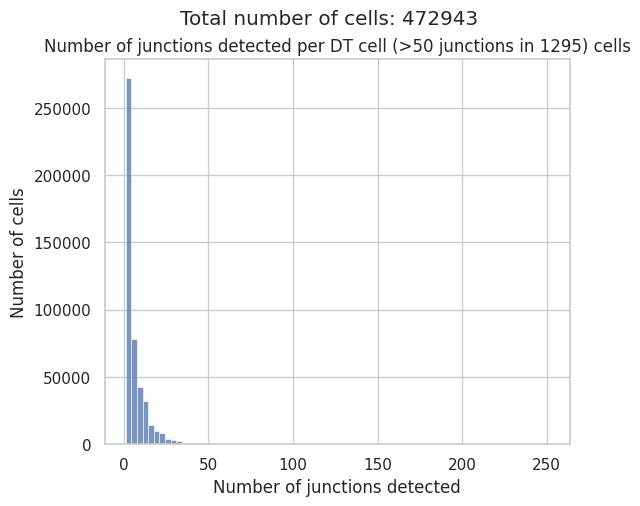

In [27]:
# plot histogram of number of junctions across cells 
plt.figure(figsize=(6, 5))
sns.histplot(junctions_per_cell.junction_id, bins=75)
plt.xlabel("Number of junctions detected")
plt.ylabel("Number of cells")

# num of cells with more than 50 junctions
n_manyjuncs = len(junctions_per_cell[junctions_per_cell.junction_id > 50])

# to title, add the total number of cells with more than 50 junctions 
plt.title("Number of junctions detected per DT cell (>50 junctions in " + str(n_manyjuncs) + ") cells")
# add subtitle, total number of cells here is 
plt.suptitle("Total number of cells: " + str(len(junctions_per_cell)))

In [28]:
# rewrite the summarized data to a new file h5 format 
# summarized_data.to_hdf(model_input_data, key='df', mode='w', complevel=9, complib='zlib', format="table")  

In [29]:
# RH juncs bed file
juncs_rh = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_juncs_RH.bed"
juncs_rh = pd.read_csv(juncs_rh, sep="\t", header=None)
# remove columns 3 and 4 
juncs_rh = juncs_rh.drop(columns=[3, 4])
juncs_rh.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]
juncs_rh

,Chromosome,Start,End,Strand,junction_id,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,1,100087912,100091792,+,1_100087912_100091792,100087762,100087912,ENSMUSG00000067028.12,Cntnap5b,ENSMUST00000086738.10,ENSMUSE00000987173.2
1,1,100087912,100141391,+,1_100087912_100141391,100087762,100087912,ENSMUSG00000067028.12,Cntnap5b,ENSMUST00000086738.10,ENSMUSE00000987173.2
2,1,100091964,100141391,+,1_100091964_100141391,100091792,100091964,ENSMUSG00000067028.12,Cntnap5b,ENSMUST00000086738.10,ENSMUSE00001050398.2
3,1,10108569,10115300,+,1_10108569_10115300,10108441,10108569,ENSMUSG00000056763.17,Cspp1,ENSMUST00000071087.12,ENSMUSE00000702887.3
4,1,10110104,10115300,+,1_10110104_10115300,10110009,10110104,ENSMUSG00000056763.17,Cspp1,ENSMUST00000119714.8,ENSMUSE00000712455.2
...,...,...,...,...,...,...,...,...,...,...,...
28557,Y,1168185,1169122,-,Y_1168185_1169122,1168089,1168185,ENSMUSG00000068457.15,Uty,ENSMUST00000143286.8,ENSMUSE00001298232.2
28558,Y,1168185,1169964,-,Y_1168185_1169964,1168089,1168185,ENSMUSG00000068457.15,Uty,ENSMUST00000143286.8,ENSMUSE00001298232.2
28559,Y,1169257,1169964,-,Y_1169257_1169964,1169122,1169257,ENSMUSG00000068457.15,Uty,ENSMUST00000069309.14,ENSMUSE00001237954.2
28560,Y,1245216,1245406,-,Y_1245216_1245406,1245155,1245216,ENSMUSG00000068457.15,Uty,ENSMUST00000139365.8,ENSMUSE00000817544.2


In [30]:
# how amny of these junctions ids are in the DT junctions file dat_vis
len(set(juncs_rh.junction_id).intersection(set(dat_vis.junction_id)))

16145

### Now we have everything need to run the Leaflet mixture model! Please refer to the next notebook for the next steps.